# Explainable Arrhythmia Detection With Wavelet Features for Intra-Patient and Inter-Patient ECG Classification

## Introduction
Early detection of arrhythmia is crucial in managing cardiac health in medicine. This is often done manually and on a beat-by-beat basis, thereby making real time monitoring in some critical cases signicantly challenging to human experts. In this project, we propose the use a decision tree(DT) machine learning model to classify and predict heart rhythms based on wavelet features for early diagnosis. This is particularly important in realtime, long-term monitoring of patients in resource constrained environements. Medical data is characteristcally very limited due to regulation and privacy rules. This makes the choice of DT models very attractive, as they generally do not require massive data to train, unlike neural network based models.

Another fundamental motivation for this approach is the critical need for clinical interpretability and transparency required in medical diagnosis. While deep learning models have been shown to effectively analyse Electrocardiogram (ECG) signals, they provide limited information to professionals on why they succeed or fail in most cases. Such blackbox models are particularly problematic in cardiology, where a diagnosis must be backed with physiological eveidence. By crafting wavelet features from the signals to define their spectral properties at the different resolutions or decomposition levels, we aim to detect arrhythmia in heart rhythms with reasonable accuracy. The model is therefore trained to learn which features are relavant to detect what heart conditions, and which magnitudes can be set as permissible limits.

To evaluate our model, results from two training scenarios are observed. One where some part of the patient's data is available during training (intra-patient mode). This is useful for models deployed online, where the they are continuously trained wih the data of the patient. A typical example would be in wearable devices, where they are personalised or customized to the user's specific ECG information. The other scenario is where the patient's data have been excluded from training entirely (inter-patient mode). This is often regarded as a more "realistic" setting or, in this case, the offline setting. In this case the model is trained as a one-size-fits all, where the model is trained only once on a given, and then applied to a various other samples that may not have been available during training.

In order to understand how much peformance gain or cost is achieved, the results are evaluated against two other classifiers namely logistic regression(LR) and XGBOOST(XGB). The results from the LR classifier provide a baseline performance to compare with our proposed DT model. This helps to highlight how much accuracy is gained by this choice while maintaining and even improving transparency with neglible tradeoff in portability. On the other hand, the XGB results provide the strong benchmark from blackbox models (XGBOOST), to also evaluate the performance cost of the proposed DT model where interpretability and portability is not a material constraint.


In [2]:
#import libraries
import wfdb
import os
import random
from collections import Counter
import pandas as pd
import numpy as np
import pywt
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV, StratifiedKFold, StratifiedGroupKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score, roc_curve, auc
import shap
import warnings
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import label_binarize


In [3]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    # If you eventually use TensorFlow/PyTorch, add their seeds here
    print(f"Global seed set to: {seed}")

seed_everything(42)

Global seed set to: 42


## Data Outline
For this project, we used the MIT-BIH Arrhythmia Database. This is a publicly available database used in medical research. It serves as benchmark for our experiment as it has been evaluated with various methods. The *<a href="https://archive.physionet.org/physiobank/database/html/mitdbdir/intro.htm">database</a>* contains heartbeats from a total of 48 patients recorded for 30 minutes each and  sampled at 360 Hz with 23 annotations. Following the Association for the Advancement of Medical Instrumentation (AAMI) standard, the 18 of the initial 23 annotations are further grouped into 5 categories of namely:
* Non-Ectopic(N) - Normal (N), Left/Right Bundle Branch Blocks (L, R), Atrial/Nodal Escapes (e, j).
* Supraventricular(S) - Atrial Premature (A), Aberrated (a), Nodal Premature (J), Supraventricular Premature (S).
* Ventricular(V) - Premature Ventricular Contraction (V), Ventricular Escape (E).
* Fusion(F) - Fusion of Ventricular and Normal (F).
* Unknown/Other(Q) - Paced (/), Fusion of Paced (f), Unclassifiable (Q).

In [4]:
# load data folder
data_dir = 'data/mit-bih-arrhythmia-database-1.0.0'

# find all .hea files and extract the record name (e.g., '100' from '100.hea')
record_names = [f.replace('.hea', '') for f in os.listdir(data_dir) if f.endswith('.hea')]
record_names.sort()

print(f"Found {len(record_names)} original records: {record_names}")

Found 48 original records: ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']


In [5]:
all_labels = []

# loop through every record found to get the attributes of the signal
for name in record_names:
    file_path = os.path.join(data_dir, name)
    try:
        ann = wfdb.rdann(file_path, 'atr')
        all_labels.extend(ann.symbol)
    except Exception as e:
        print(f"Could not read record {name}: {e}")

# count the amount of each feature annotation
counts = Counter(all_labels)
df_counts = pd.DataFrame.from_dict(counts, orient='index', columns=['Count']).sort_values('Count', ascending=False)

print(df_counts)

   Count
N  75052
L   8075
R   7259
V   7130
/   7028
A   2546
+   1291
f    982
F    803
~    616
!    472
"    437
j    229
x    193
a    150
|    132
E    106
J     83
Q     33
e     16
[      6
]      6
S      2


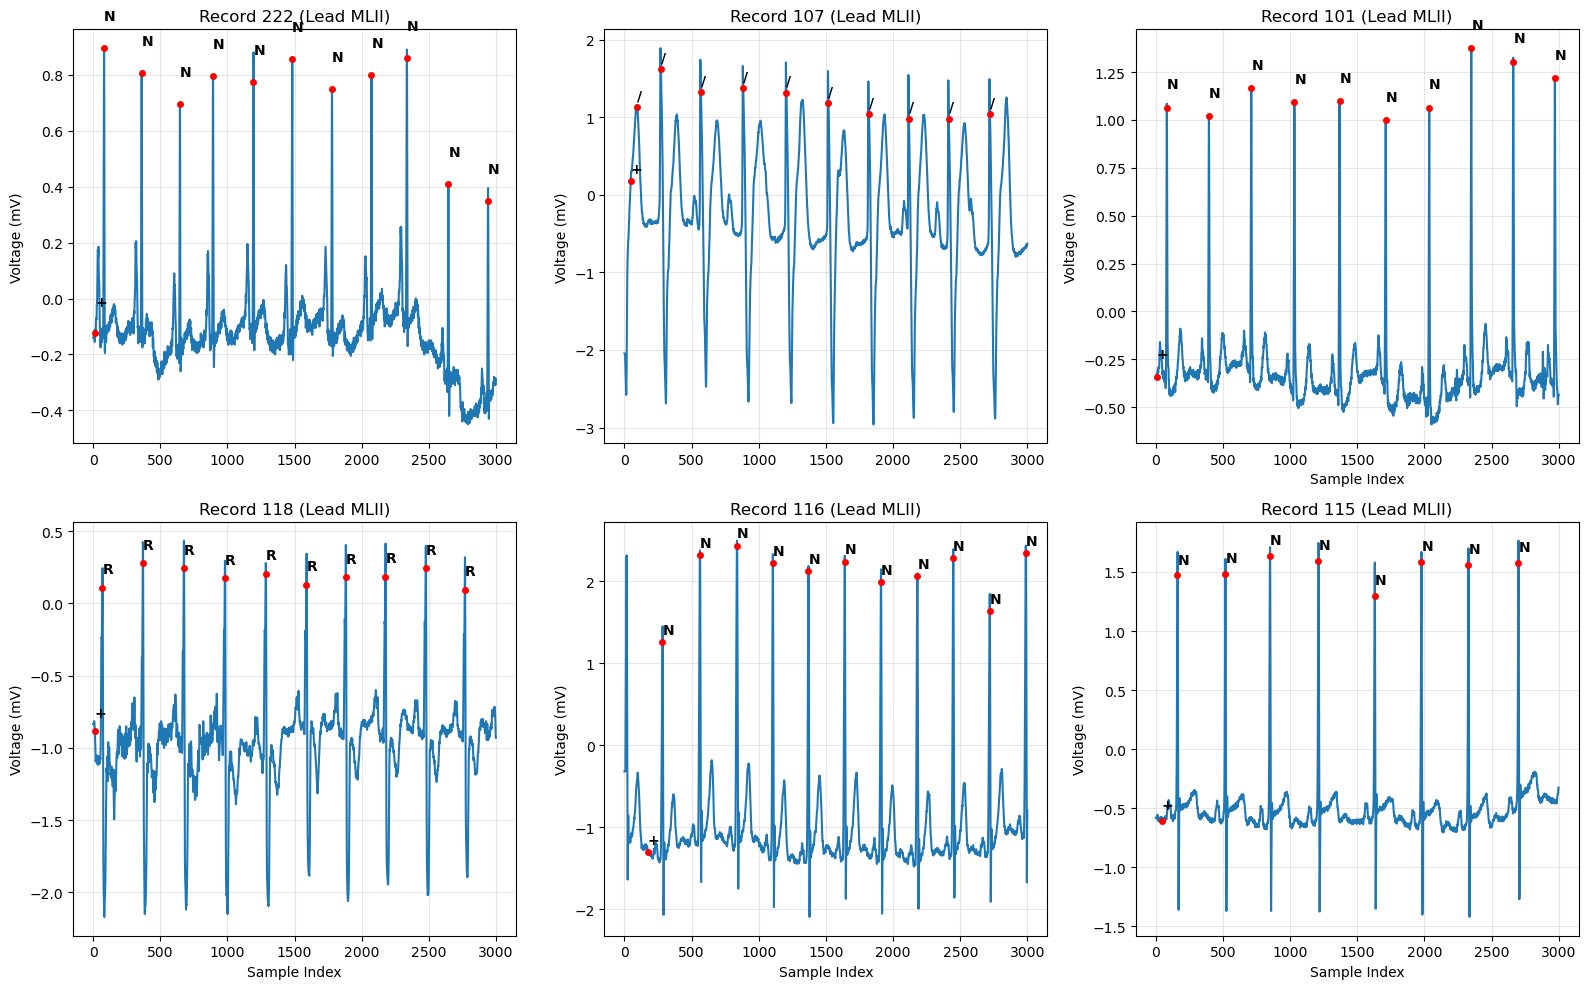

In [6]:
# randomly sample signals from the database and plot
n_plots = min(len(record_names), 6)
random_records = random.sample(record_names, n_plots)

# create the subplot grid
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes_flat = axes.flatten() 

# loop using the number of records selected
for i in range(n_plots):
    record_name = random_records[i]
    path = os.path.join(data_dir, record_name)
    
    # load signal and annotations
    record = wfdb.rdrecord(path, sampto=3000)
    annotation = wfdb.rdann(path, 'atr', sampto=3000)
    
    ax = axes_flat[i]
    signal = record.p_signal[:, 0]
    ax.plot(signal, color='#1f77b4', label=f'Lead: {record.sig_name[0]}')
    
    # overlay annotations
    for j in range(len(annotation.sample)):
        idx = annotation.sample[j]
        sym = annotation.symbol[j]
        volt = signal[idx]
        
        ax.plot(idx, volt, 'ro', markersize=4)
        ax.text(idx, volt + 0.1, sym, fontsize=10, fontweight='bold')
    
    ax.set_title(f"Record {record_name} (Lead {record.sig_name[0]})", fontsize=12)
    ax.set_ylabel("Voltage (mV)")
    ax.grid(True, alpha=0.3)
    if i >= 2: ax.set_xlabel("Sample Index")

plt.tight_layout()
plt.show()

In [7]:
# analysing a specific signal
# load signal
record_name = '208'
file_path = os.path.join(data_dir, record_name)

# read the annotation file (.atr)
ann = wfdb.rdann(file_path, 'atr')

print(f"Annotations for Record {record_name}")
# print the first 10 beat locations and their symbols
for i in range(10):
    print(f"Beat {i}: Sample Index: {ann.sample[i]:<6} | Symbol: {ann.symbol[i]}")

# signal properties
record = wfdb.rdrecord(file_path, sampto=3000)
print("-----Signal Properties-----")
print(f"Sampling Frequency: {record.fs} Hz")
print(f"Signal Shape: {record.p_signal.shape}")
print(f"Signals (Leads) present: {record.sig_name}")
print(f"Units: {record.units}")

Annotations for Record 208
Beat 0: Sample Index: 9      | Symbol: +
Beat 1: Sample Index: 46     | Symbol: F
Beat 2: Sample Index: 209    | Symbol: V
Beat 3: Sample Index: 483    | Symbol: N
Beat 4: Sample Index: 697    | Symbol: F
Beat 5: Sample Index: 853    | Symbol: V
Beat 6: Sample Index: 1181   | Symbol: N
Beat 7: Sample Index: 1378   | Symbol: V
Beat 8: Sample Index: 1579   | Symbol: V
Beat 9: Sample Index: 1860   | Symbol: N
-----Signal Properties-----
Sampling Frequency: 360 Hz
Signal Shape: (3000, 2)
Signals (Leads) present: ['MLII', 'V1']
Units: ['mV', 'mV']


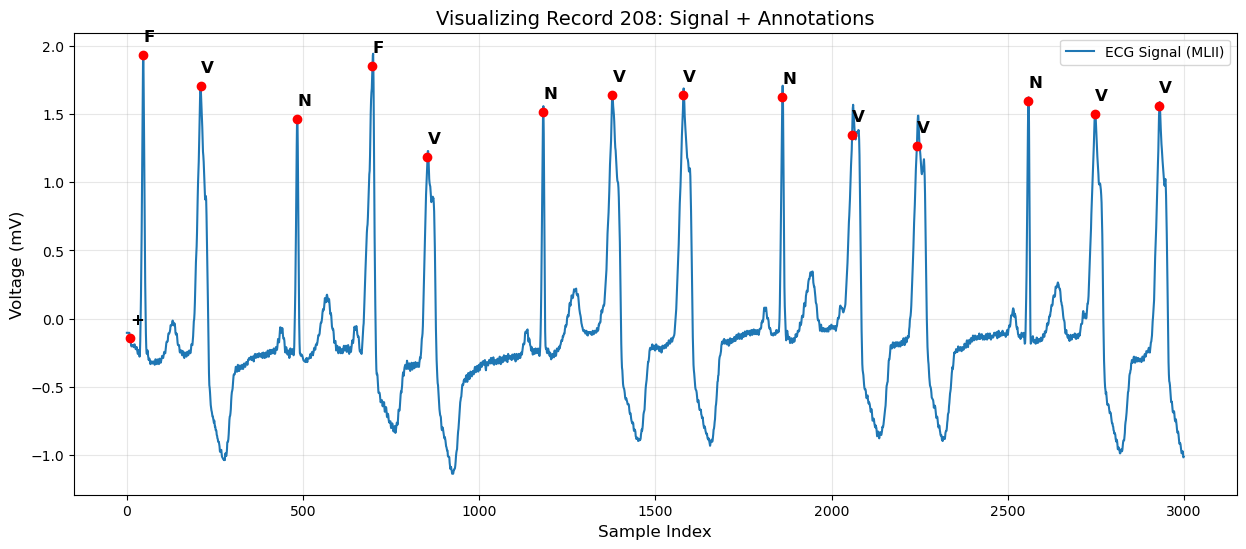

In [8]:
# plotting signal 208 with the annotations
annotation = wfdb.rdann(file_path, 'atr', sampto=3000)
plt.figure(figsize=(15, 6))
plt.plot(record.p_signal[:, 0], color='#1f77b4', label='ECG Signal (MLII)')

# mark the annotation points
# we plot the 'symbol' at the height of the signal at that 'sample' index
for i in range(len(annotation.sample)):
    sample_idx = annotation.sample[i]
    symbol = annotation.symbol[i]
    # get the voltage at that specific sample to place the label correctly
    voltage = record.p_signal[sample_idx, 0]
    
    plt.plot(sample_idx, voltage, 'ro') # Red dot for the peak
    plt.text(sample_idx, voltage + 0.1, symbol, fontsize=12, fontweight='bold')

plt.title(f"Visualizing Record {record_name}: Signal + Annotations", fontsize=14)
plt.xlabel("Sample Index", fontsize=12)
plt.ylabel("Voltage (mV)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

## Feature Engineering and Extraction

An observation of the heartbeat signals reveal that while there is a global sinus rhythm, there are also local rhythms within the global structure. This is important as beats are often distinguished from one another by their magnigtudes, shapes and sequences within the signal segment. From the sample signal 208 plotted, the Normal(N) beats are characterised by sharp, slender, symmetric and regularly spaced between themselves. On the other hand, the Premature Ventricular Contraction(V) beats are characterized by wider, non-symmetric or skewed and irregularly spaced, while the Fusion(F) beats appear to have the highest magnitude within a sequence of beats. So by charaterizing each beat by parameters that define these features, we proceed to train a machine learning model to classify beats based on these features with reasonable accuracy.

The signal features can be defined by the randomness of the signal within a defined segment (entropy), the magnitude of a sample with respect to the neigbouring samples (relative energy), the shape of the segment (skewness), the |sharpness" or "bluntness" of a segment(kurtosis) and the difference between successive peaks (Pre_RR, Post_RR, RR_Ratio). This is where the wavelet transform is benefificial with its unique property of decomposing signals into different frequency bands while preserving their position in the sequence. This ensures that these signals are analysed at different fequency levels to capture their global and local properties effectively and evaluating which frequencies are the most discriminative in the describing a beat. 


**Sub-band Energy and Relative Power:**
The energy $E_j$ of a specific wavelet decomposition level $j$ is calculated as the sum of the squares of its coefficients:
$$E_j = \sum_{k=1}^{n} |C_{j,k}|^2$$

To capture the **Relative Energy** ($P_j$) or the percentage of power distribution across the frequency bands, we use:
$$P_j = \frac{E_j}{\sum E_{total}} \times 100\%$$

**Morphological Descriptors:**
To quantify the symmetry and sharpness of the QRS complex, we calculate the **Skewness** ($\gamma_1$) and **Kurtosis** ($\gamma_2$) of the wavelet coefficients at level $j$:

**Skewness (Asymmetry):**
$$\gamma_{1,j} = \frac{\frac{1}{n} \sum_{k=1}^{n} (C_{j,k} - \mu_j)^3}{\sigma_j^3}$$

**Kurtosis (Peakiness/Sharpness):**
$$\gamma_{2,j} = \frac{\frac{1}{n} \sum_{k=1}^{n} (C_{j,k} - \mu_j)^4}{\sigma_j^4}$$

*Where $\mu_j$ is the mean and $\sigma_j$ is the standard deviation of the coefficients $C_{j,k}$.*

**Shannon Entropy:**
The complexity of the signal within a specific sub-band is represented by Shannon Entropy ($H$):
$$H_j = -\sum_{k} p(C_{j,k}) \log_2 p(C_{j,k})$$

**Temporal (Rhythm) Features:**
The global rhythm is captured by analyzing the time intervals between successive R-peaks ($R_i$):

* **Pre-RR Interval:** $\Delta R_{pre} = R_i - R_{i-1}$
* **Post-RR Interval:** $\Delta R_{post} = R_{i+1} - R_i$
* **RR-Ratio:** $RR_{ratio} = \frac{\Delta R_{pre}}{\Delta R_{post}}$

#### DWT Frequency Band Calculation
The Discrete Wavelet Transform (DWT) decomposes the ECG signal $x[t]$ into a set of basis functions derived from a single Mother Wavelet $\psi(t)$. These basis functions, $\psi_{j,k}(t)$, are generated by scaling (dilating) and shifting (translating) the mother wavelet:

$$\psi_{j,k}(t) = 2^{-j/2} \psi(2^{-j}t - k)$$

Where:
* $j$ is the scale (decomposition level), determining the frequency band.
* $k$ is the translation (time shift), determining the position in the signal.

**Multi-Resolution Analysis (MRA)**
The DWT is implemented using a cascade of digital filters. The signal is simultaneously passed through a high-pass filter $g[n]$ and a low-pass filter $h[n]$. This results in the Detail and Approximation coefficients at each level $j$:

**Detail Coefficients (High Frequency):**
$$D_j[k] = \sum_{n} x[n] \cdot g[2k - n]$$

**Approximation Coefficients (Low Frequency):**
$$A_j[k] = \sum_{n} x[n] \cdot h[2k - n]$$
  
The frequency ranges for the decomposition levels are derived using Dyadic Decimation. Given a sampling frequency ($f_s$) of 360 Hz, the Nyquist frequency is $f_n = 180$ Hz. This 180 Hz represents the total bandwidth available for analysis.

## Decomposition Table: The Halving Process
| Level | Halving Logic (Remaining Bandwidth) | Frequency Range | Physiological Significance |
| :--- | :--- | :--- | :--- |
| **D1** | $180$ Hz $\div 2$ | 90 – 180 Hz | High-frequency Noise / Sharp Edges |
| **D2** | $90$ Hz $\div 2$ | 45 – 90 Hz | QRS Sharpness (R-peak tip) |
| **D3** | $45$ Hz $\div 2$ | 22.5 – 45 Hz | QRS Complex Main Body |
| **D4** | $22.5$ Hz $\div 2$ | 11.25 – 22.5 Hz | Wider Body |
| **A4** | Remaining Lower Half | 0 – 11.25 Hz | Baseline Wander / P & T Waves |

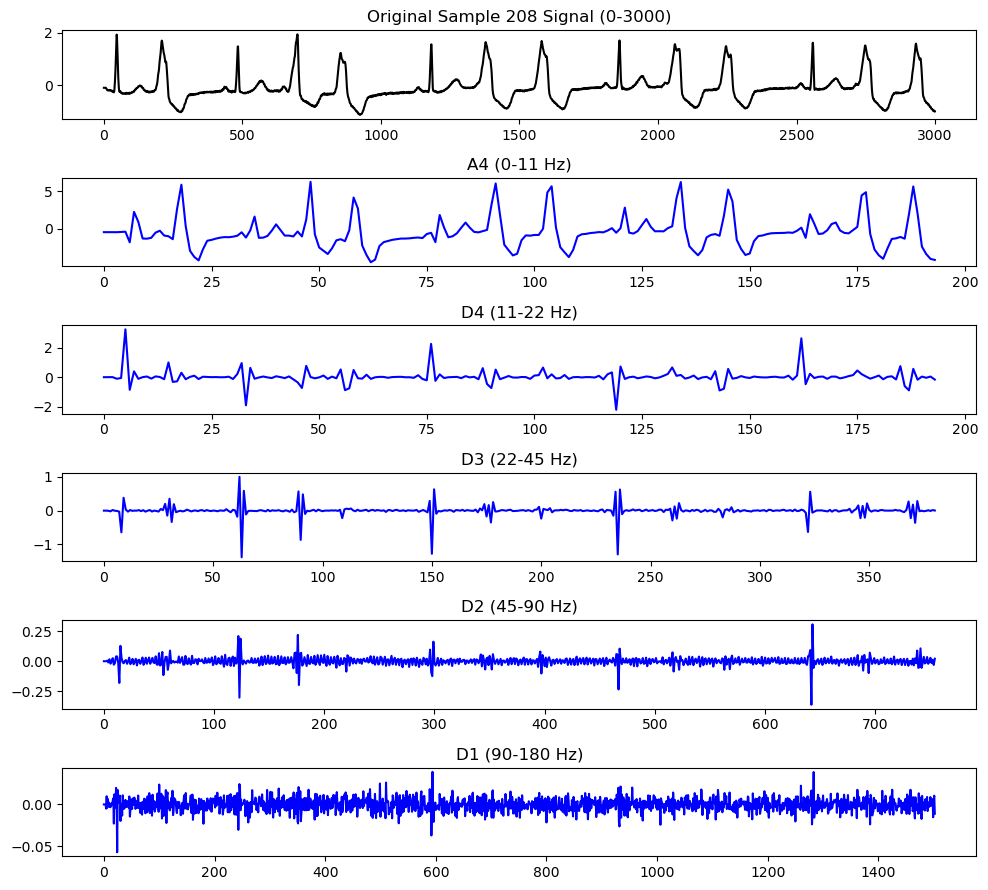

In [9]:
# decompose the sample signal 208 with DWT
signal_3000 = record.p_signal[0:3000, 0]

# apply DWT (using the 'db4' wavelet you used for the energy table)
coeffs = pywt.wavedec(signal_3000, 'db4', level=4)  #the Daubechies 4 (db4) wavelet
# coeffs[0] = A4 (Lowest frequencies - the "baseline")
# coeffs[1] = D4 (Lower frequencies - wide shapes)
# coeffs[2] = D3 (Medium frequencies)
# coeffs[3] = D2 (High frequencies - sharp spikes)
# coeffs[4] = D1 (Highest frequencies - noise)

# plot the layers to compare with the CWT
fig, axes = plt.subplots(len(coeffs) + 1, 1, figsize=(10, 9), sharex=False)

# plot original sample 208 signal
axes[0].plot(signal_3000, color='black')
axes[0].set_title("Original Sample 208 Signal (0-3000)")

# plot DWT Levels (The "Frequency Buckets")
names = ['A4 (0-11 Hz)', 'D4 (11-22 Hz)', 'D3 (22-45 Hz)', 'D2 (45-90 Hz)', 'D1 (90-180 Hz)']
for i, (c, name) in enumerate(zip(coeffs, names)):
    axes[i+1].plot(c, color='blue')
    axes[i+1].set_title(name)

plt.tight_layout()
plt.show()

In [10]:
def extract_wavelet_features(beat_segment):
    # Decomposition Level 4 using Daubechies 4 (db4)
    coeffs = pywt.wavedec(beat_segment, 'db4', level=4) # Order: A4, D4, D3, D2, D1
    
    features = []
    # Calculate Total Energy for Relative Ratios
    energies = [np.sum(np.square(c)) for c in coeffs]
    total_energy = np.sum(energies) + 1e-12

    for c in coeffs:
        # relative energy: spectral volume
        level_energy = np.sum(np.square(c))
        features.append((level_energy / total_energy) * 100)
        
        # shannon entropy: signal randomness
        p = np.square(c) / (level_energy + 1e-12)
        entropy = -np.sum(p * np.log2(p + 1e-12))
        features.append(entropy)
        
        # kurtosis: sharpness of the peak
        features.append(kurtosis(c))
        
        # skewness: asymmetry of the wave
        features.append(skew(c))
        
    return features
    
# configuration
data_dir = 'data/mit-bih-arrhythmia-database-1.0.0'
output_csv = 'mit_bih_wavelet_features.csv'

# Check if the file already exists
if os.path.exists(output_csv):
    print(f"File '{output_csv}' found. Loading data from CSV...")
    df = pd.read_csv(output_csv)
    print("Data loaded successfully!")
else:
    print(f"CSV not found. Starting extraction process...")
    
    # 1. Get the record names
    record_names = [f.replace('.hea', '') for f in os.listdir(data_dir) if f.endswith('.hea')]
    record_names.sort()

    all_feature_data = []

    # 2. Extraction Loop
    for name in record_names:    
        record_path = os.path.join(data_dir, name)        
        try:
            record = wfdb.rdrecord(record_path)
            annotation = wfdb.rdann(record_path, 'atr')
            
            for i in range(1,len(annotation.sample)-1):
                idx = annotation.sample[i]
                label = annotation.symbol[i]
                pre_rr = idx - annotation.sample[i-1]   # Distance to previous peak
                post_rr = annotation.sample[i+1] - idx  # Distance to next peak
                rr_ratio = pre_rr / (post_rr + 1e-12)   # Detects sudden changes
                
                # Capture window around R-peak
                if idx - 90 > 0 and idx + 90 < len(record.p_signal):
                    beat_segment = record.p_signal[idx-90 : idx+90, 0]
                    
                    # Extract features using your function
                    features = extract_wavelet_features(beat_segment)
                    features.append(pre_rr)
                    features.append(post_rr)
                    features.append(rr_ratio)
                    features.append(label)
                    features.append(name) 
                    all_feature_data.append(features)
                    
        except Exception as e:
            print(f"Error loading record {name}: {e}")

    # 3. Create DataFrame and Save
    # 3. Create DataFrame and Save
    # Corrected column order to match the loop: Level by Level (A4 -> D4 -> D3 -> D2 -> D1)
    columns = [
    'A4_Energy', 'A4_Entropy', 'A4_Kurtosis', 'A4_Skewness',
    'D4_Energy', 'D4_Entropy', 'D4_Kurtosis', 'D4_Skewness',
    'D3_Energy', 'D3_Entropy', 'D3_Kurtosis', 'D3_Skewness',
    'D2_Energy', 'D2_Entropy', 'D2_Kurtosis', 'D2_Skewness',
    'D1_Energy', 'D1_Entropy', 'D1_Kurtosis', 'D1_Skewness',
    'Pre_RR', 'Post_RR', 'RR_Ratio', 
    'Label', 'Record_ID'
]
    
    df = pd.DataFrame(all_feature_data, columns=columns)
    
    # Save as CSV (index=False prevents an extra column of row numbers)
    df.to_csv(output_csv, index=False)
    print(f"Extraction complete and saved to '{output_csv}'!")

# Display the result (works whether you just extracted or just loaded)
print(f"Total rows: {len(df)}")
df.head()

File 'mit_bih_wavelet_features.csv' found. Loading data from CSV...
Data loaded successfully!
Total rows: 112536


,A4_Energy,A4_Entropy,A4_Kurtosis,A4_Skewness,D4_Energy,D4_Entropy,D4_Kurtosis,D4_Skewness,D3_Energy,D3_Entropy,...,D2_Skewness,D1_Energy,D1_Entropy,D1_Kurtosis,D1_Skewness,Pre_RR,Post_RR,RR_Ratio,Label,Record_ID
0,90.278202,3.928771,6.187926,2.252972,4.248662,0.494336,9.620565,-3.081646,5.268517,1.582488,...,-0.648953,0.018344,4.858640,3.469378,0.623992,293,292,1.003425,N,100
1,89.396765,3.913260,5.065359,1.930603,2.589471,0.540406,9.912771,-3.213862,7.208453,1.326411,...,-1.975563,0.027859,3.905108,12.940970,-1.374660,292,284,1.028169,N,100
2,90.511390,3.899858,5.174406,1.505931,2.892183,0.410633,10.445305,-3.355822,5.891662,1.349966,...,-1.348658,0.018014,4.437948,6.629536,-0.770983,284,285,0.996491,N,100
3,91.439925,3.922658,5.094643,1.979423,2.812204,0.596854,9.337306,-3.069057,5.503951,1.126950,...,-0.376036,0.016303,4.684230,3.900260,0.574319,285,284,1.003521,N,100
4,90.554910,3.912613,4.900097,1.933762,3.832092,0.793809,8.113354,-2.832093,5.369416,1.112625,...,1.005355,0.014977,4.704673,4.369706,0.560013,284,294,0.965986,N,100


In [11]:
df.describe()

,A4_Energy,A4_Entropy,A4_Kurtosis,A4_Skewness,D4_Energy,D4_Entropy,D4_Kurtosis,D4_Skewness,D3_Energy,D3_Entropy,...,D2_Kurtosis,D2_Skewness,D1_Energy,D1_Entropy,D1_Kurtosis,D1_Skewness,Pre_RR,Post_RR,RR_Ratio,Record_ID
count,112536.000000,112536.000000,112536.000000,112536.000000,112536.000000,112536.000000,112536.000000,112536.000000,112536.000000,112536.000000,...,112536.000000,112536.000000,112536.000000,112536.000000,112536.000000,112536.000000,112536.000000,112536.000000,112536.000000,112536.000000
mean,91.240654,3.405505,4.438334,1.689384,3.093244,1.400162,5.318330,-1.062706,5.272319,1.748955,...,8.724257,-0.266106,0.024417,4.855446,4.717366,0.054911,277.023975,277.072004,1.054164,171.203002
std,8.598990,0.622459,3.207009,1.193486,2.960005,0.579408,2.727091,1.635722,5.951689,0.582263,...,6.100919,1.205069,0.040933,0.825503,7.778501,0.896410,81.780431,81.746875,0.483919,52.583327
min,29.713739,0.257672,-1.927059,-3.394359,0.000015,0.089187,-1.452714,-3.697450,0.000093,0.176706,...,-1.433038,-5.615654,0.000009,1.023133,-1.107998,-6.884084,6.000000,6.000000,0.020833,100.000000
25%,87.009210,3.070633,1.428000,0.968405,1.054694,0.976524,3.187099,-2.458268,0.759955,1.398730,...,3.310811,-1.043716,0.005123,4.643088,0.274930,-0.305187,231.000000,231.000000,0.966361,113.000000
50%,94.483196,3.626363,4.648708,2.023253,2.159690,1.351594,5.200916,-1.368697,3.043734,1.567995,...,8.570902,-0.214405,0.013551,5.166843,1.441207,0.003931,271.000000,271.000000,1.003436,203.000000
75%,97.645961,3.909997,7.167433,2.602946,4.407815,1.761883,7.451819,0.208377,8.050466,1.970345,...,13.644205,0.451720,0.028059,5.399128,5.320128,0.318356,318.000000,318.000000,1.044248,217.000000
max,99.999827,4.087209,12.020843,3.741116,55.938714,3.555514,11.812157,3.684891,49.333210,4.340658,...,34.709217,5.420820,3.704152,5.906776,67.301098,7.731931,2114.000000,2114.000000,53.833333,234.000000


In [12]:
# create a copy for analysis
dataset = df.copy()

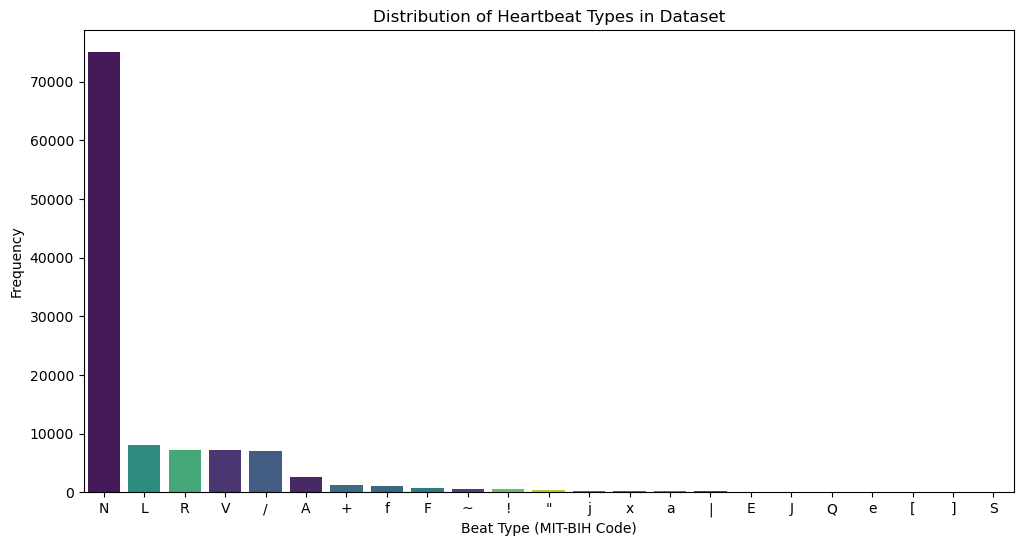

In [13]:
# ploting the distribution of the features
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df, 
    x='Label', 
    order=df['Label'].value_counts().index, 
    palette='viridis',
    hue='Label',
    legend=False
)

plt.title('Distribution of Heartbeat Types in Dataset')
plt.xlabel('Beat Type (MIT-BIH Code)')
plt.ylabel('Frequency')
plt.show()

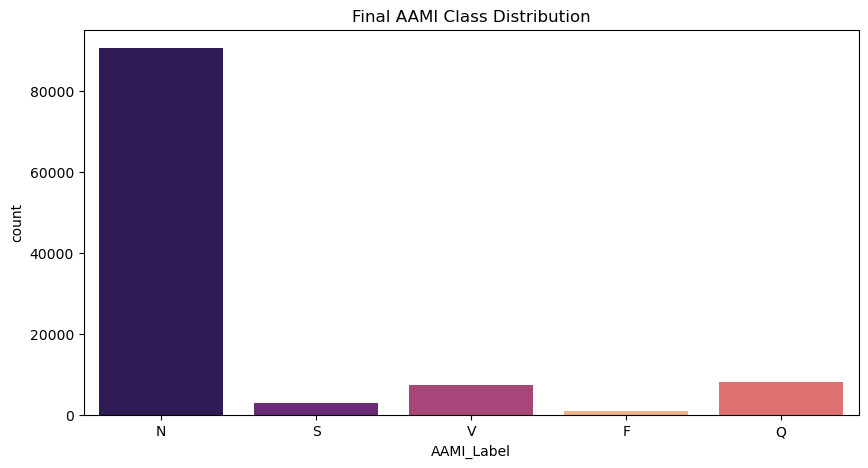

In [14]:
# define the AAMI mapping and grouping
aami_map = {
    # N (Normal) group
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    
    # S (Supraventricular Ectopic) group
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    
    # V (Ventricular Ectopic) group
    'V': 'V', 'E': 'V',
    
    # F (Fusion) group
    'F': 'F',
    
    # Q (Unknown/Paced) group
    '/': 'Q', 'f': 'Q', 'Q': 'Q'
}

# create a new column for the AAMI category
df['AAMI_Label'] = df['Label'].map(aami_map)

# drop the rows that didn't map to a category (the noise/rhythm markers)
# This removes notations like '+', '~', '!', '"', '|', 'x', '[', ']'
df_cleaned = df.dropna(subset=['AAMI_Label']).copy()

# plot the group dataframe
plt.figure(figsize=(10, 5))
sns.countplot(data=df_cleaned, x='AAMI_Label', 
              order=['N', 'S', 'V', 'F', 'Q'], 
              palette='magma', hue='AAMI_Label', legend=False)
plt.title('Final AAMI Class Distribution')
plt.show()

In [15]:
df_cleaned.head(3)

,A4_Energy,A4_Entropy,A4_Kurtosis,A4_Skewness,D4_Energy,D4_Entropy,D4_Kurtosis,D4_Skewness,D3_Energy,D3_Entropy,...,D1_Energy,D1_Entropy,D1_Kurtosis,D1_Skewness,Pre_RR,Post_RR,RR_Ratio,Label,Record_ID,AAMI_Label
0,90.278202,3.928771,6.187926,2.252972,4.248662,0.494336,9.620565,-3.081646,5.268517,1.582488,...,0.018344,4.858640,3.469378,0.623992,293,292,1.003425,N,100,N
1,89.396765,3.913260,5.065359,1.930603,2.589471,0.540406,9.912771,-3.213862,7.208453,1.326411,...,0.027859,3.905108,12.940970,-1.374660,292,284,1.028169,N,100,N
2,90.511390,3.899858,5.174406,1.505931,2.892183,0.410633,10.445305,-3.355822,5.891662,1.349966,...,0.018014,4.437948,6.629536,-0.770983,284,285,0.996491,N,100,N


### Intra-Patient Mode:
The split is done according to the labels with very no consideration about which data belonged to which specific patient is training or in testing. Only 50% of the dataset was used in tranining to simulate the practical data constraint.

Label Distribution Across Split:
            Train   Test
AAMI_Label              
F             401    401
N           45289  45289
Q            4019   4019
S            1389   1390
V            3618   3617


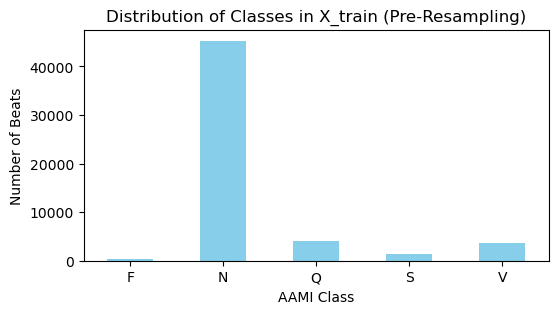

In [16]:
# prepare Features and Target
X = df_cleaned.drop(['AAMI_Label', 'Label', 'Record_ID'], axis=1)
y = df_cleaned['AAMI_Label']

# split 50/50
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.50, random_state=42, stratify=y)

# Check counts in training and testing sets
train_dist = pd.Series(y_train).value_counts().sort_index()
test_dist = pd.Series(y_test).value_counts().sort_index()

# Combine for a quick comparison table
dist_df = pd.DataFrame({'Train': train_dist, 'Test': test_dist})
print("Label Distribution Across Split:")
print(dist_df)

# visualize the training distribution to identify the imbalance
plt.figure(figsize=(6, 3))
train_dist.plot(kind='bar', color='skyblue')
plt.title('Distribution of Classes in X_train (Pre-Resampling)')
plt.ylabel('Number of Beats')
plt.xticks(rotation=0)
plt.xlabel('AAMI Class')
plt.show()

### Intra-Patient: Logistic Regression Training And Classification

In [17]:
# standardized pipeline
pipeline_lr = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('under', RandomUnderSampler(random_state=42)),
    ('over', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=2000, solver='lbfgs'))
])

# parameter grid
param_grid_lr = {
    # Test uniform target sizes for the majority class
    'under__sampling_strategy': [{'N': 10000}, {'N': 15000}, {'N': 20000}, {'N': 25000}, {'N': 30000}],
    'over__sampling_strategy': ['auto'], #brings others up to match 'N'
    
    # Model tuning
    'over__k_neighbors': [3, 5],
    'model__C': [0.1, 1.0, 10.0]
}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid_lr,
    scoring='f1_macro',  # f_1 metric
    cv=skf,  
    n_jobs=-1,
    verbose=1
)

# fit the search
print("Tuning both sampling size and model parameters...")
grid_lr.fit(X_train, y_train)

# print the best parameters and scores
print(f"Best Target Size & Params: {grid_lr.best_params_}")
print(f"Best CV Score: {grid_lr.best_score_:.4f}")

Tuning both sampling size and model parameters...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Target Size & Params: {'model__C': 10.0, 'over__k_neighbors': 5, 'over__sampling_strategy': 'auto', 'under__sampling_strategy': {'N': 30000}}
Best CV Score: 0.6126


In [18]:
# Results
best_index = grid_lr.best_index_
mean_cv_score = grid_lr.cv_results_['mean_test_score'][best_index]
std_cv_score = grid_lr.cv_results_['std_test_score'][best_index]
print(f"CV Standard Deviation: {std_cv_score}")
print(f"CV Mean F1-Score: {mean_cv_score}")

CV Standard Deviation: 0.005154338587563656
CV Mean F1-Score: 0.6126452820997976


In [19]:
print("\n LR-Intra Final Classification Report")
y_pred_lr = grid_lr.predict(X_test)
print(classification_report(y_test, y_pred_lr))


 LR-Intra Final Classification Report
              precision    recall  f1-score   support

           F       0.09      0.82      0.16       401
           N       0.99      0.79      0.88     45289
           Q       0.84      0.97      0.90      4019
           S       0.19      0.81      0.31      1390
           V       0.72      0.86      0.79      3617

    accuracy                           0.81     54716
   macro avg       0.57      0.85      0.61     54716
weighted avg       0.93      0.81      0.85     54716



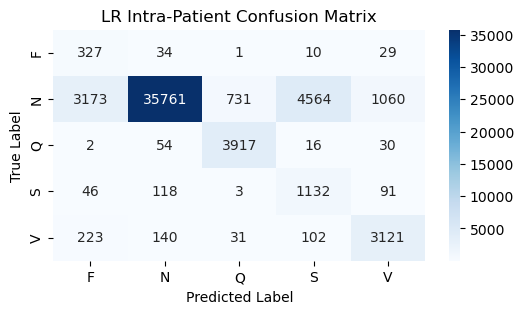

In [20]:
# generate confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
labels = sorted(y_test.unique())

# plot
plt.figure(figsize=(6, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('LR Intra-Patient Confusion Matrix')
plt.show()

### Intra-Patient Decision Tree Training And Classification

In [21]:
# define the Pipeline
pipeline_dt = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('under', RandomUnderSampler(random_state=42)),
    ('over', SMOTE(random_state=42)),
    ('model', DecisionTreeClassifier(random_state=42))
])

# define the Grid
param_grid_dt = {
    # Identical sampling strategy
    'under__sampling_strategy': [{'N': 10000}, {'N': 15000}, {'N': 20000}, {'N': 25000}, {'N': 30000}],
    'over__sampling_strategy': ['auto'],
    
    # Tamed hyperparameters to prevent severe overfitting
    'model__max_depth': [4, 6, 8, 10, 12, 14],         
    'model__min_samples_leaf': [30, 50, 100],  # generalization
    'model__criterion': ['gini', 'entropy'],
    'model__class_weight': [None]            
}

# setup grid search
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_dt = GridSearchCV(
    estimator=pipeline_dt,
    param_grid=param_grid_dt,
    cv=skf,
    scoring='f1_macro',  # f_1 metric
    n_jobs=-1,              
    verbose=1
)

# fit
grid_dt.fit(X_train, y_train)

print(f"Best Parameters: {grid_dt.best_params_}")
print(f"Best CV Score: {grid_dt.best_score_:.4f}")


Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best Parameters: {'model__class_weight': None, 'model__criterion': 'entropy', 'model__max_depth': 14, 'model__min_samples_leaf': 30, 'over__sampling_strategy': 'auto', 'under__sampling_strategy': {'N': 30000}}
Best CV Score: 0.7437


In [22]:
# Results
best_index = grid_dt.best_index_
mean_cv_score = grid_dt.cv_results_['mean_test_score'][best_index]
std_cv_score = grid_dt.cv_results_['std_test_score'][best_index]
print(f"CV Standard Deviation: {std_cv_score}")
print(f"CV Mean F1-Score: {mean_cv_score}")

CV Standard Deviation: 0.0057783020181231114
CV Mean F1-Score: 0.7437184312269022


In [23]:
# classification report
print(" DT-Intra Final Classification Report")
y_pred_dt = grid_dt.predict(X_test)
print(classification_report(y_test, y_pred_dt))

 DT-Intra Final Classification Report
              precision    recall  f1-score   support

           F       0.21      0.81      0.34       401
           N       0.99      0.92      0.96     45289
           Q       0.92      0.98      0.95      4019
           S       0.46      0.87      0.60      1390
           V       0.79      0.93      0.85      3617

    accuracy                           0.92     54716
   macro avg       0.67      0.90      0.74     54716
weighted avg       0.95      0.92      0.93     54716



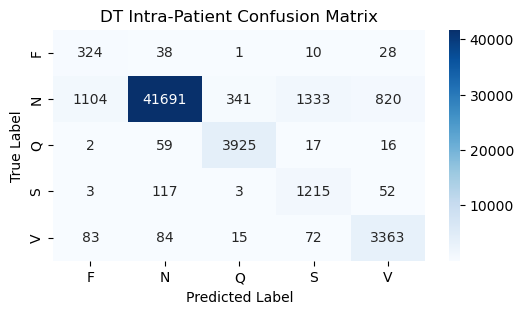

In [24]:
# generate confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)
labels = sorted(y_test.unique())

# plot
plt.figure(figsize=(6, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('DT Intra-Patient Confusion Matrix')
plt.show()

In [58]:
# Extract the actual tree from the 'model' step of the pipeline
feature_names = X_test.columns.tolist()

best_pipeline = grid_dt.best_estimator_
tree_model = best_pipeline.named_steps['model']

# Now export the logic using the extracted tree
tree_rules = export_text(tree_model, feature_names=feature_names)
print(tree_rules)

|--- D1_Entropy <= -0.54
|   |--- A4_Kurtosis <= -0.15
|   |   |--- D3_Energy <= 0.02
|   |   |   |--- Pre_RR <= -0.41
|   |   |   |   |--- D2_Skewness <= 0.44
|   |   |   |   |   |--- D2_Skewness <= -1.31
|   |   |   |   |   |   |--- class: Q
|   |   |   |   |   |--- D2_Skewness >  -1.31
|   |   |   |   |   |   |--- class: S
|   |   |   |   |--- D2_Skewness >  0.44
|   |   |   |   |   |--- D2_Entropy <= -0.79
|   |   |   |   |   |   |--- class: V
|   |   |   |   |   |--- D2_Entropy >  -0.79
|   |   |   |   |   |   |--- class: V
|   |   |   |--- Pre_RR >  -0.41
|   |   |   |   |--- Post_RR <= -0.03
|   |   |   |   |   |--- Pre_RR <= -0.08
|   |   |   |   |   |   |--- class: N
|   |   |   |   |   |--- Pre_RR >  -0.08
|   |   |   |   |   |   |--- class: Q
|   |   |   |   |--- Post_RR >  -0.03
|   |   |   |   |   |--- Pre_RR <= 0.53
|   |   |   |   |   |   |--- class: Q
|   |   |   |   |   |--- Pre_RR >  0.53
|   |   |   |   |   |   |--- class: Q
|   |   |--- D3_Energy >  0.02
|   |   |  

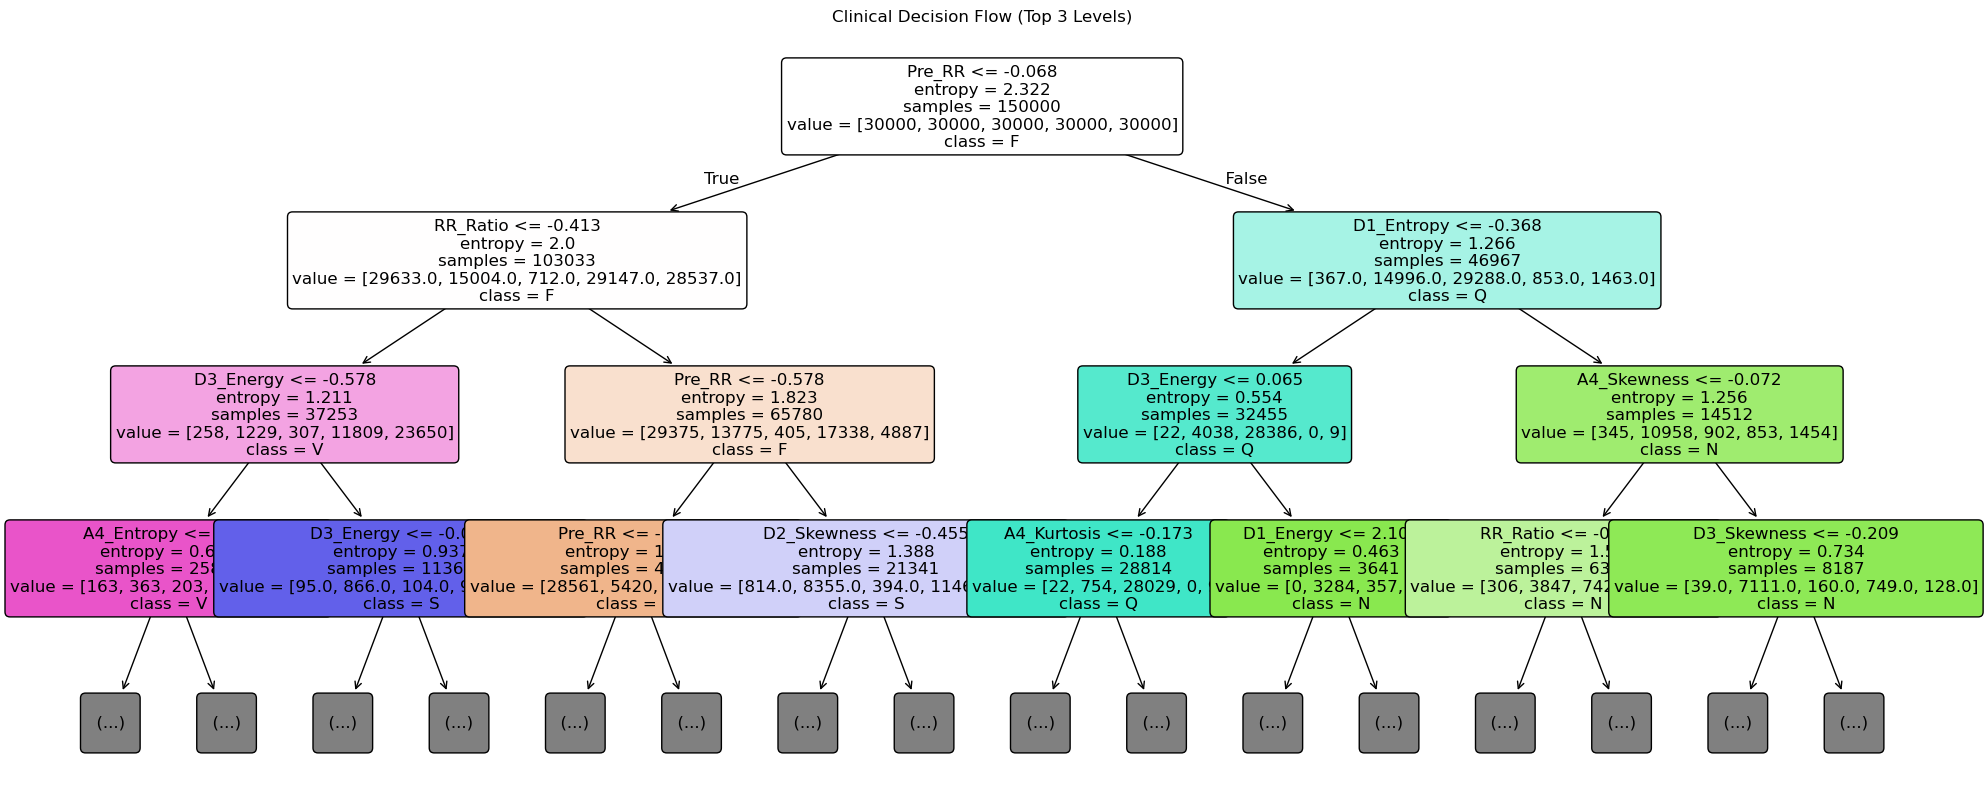

In [27]:
# extract the trained tree from the 'model' step
tree_to_plot = best_pipeline.named_steps['model']

# pass the extracted tree (not the pipeline) to plot_tree
plt.figure(figsize=(24, 10))
plot_tree(
    tree_to_plot,                
    max_depth=3,                  
    feature_names=feature_names,   
    class_names=labels,            
    filled=True,                   
    rounded=True,      
    fontsize=12     
)
plt.title("Clinical Decision Flow (Top 3 Levels)")
plt.show()

### Intra-Patient: XGBOOST Training And Classification

In [28]:
# label encoding
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

# define the Pipeline
xgb_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('under', RandomUnderSampler(random_state=42)),
    ('over', SMOTE(random_state=42)),
    ('model', XGBClassifier(random_state=42))
])

# define the hyperparameter grid
N_encoded = le.transform(['N'])[0]
param_grid_xgb = {
    # Identical sampling strategy using the encoded integer key
    'under__sampling_strategy': [{N_encoded: 10000}, {N_encoded: 15000}, {N_encoded: 20000}, {N_encoded: 25000},{N_encoded: 30000}], 
    'over__sampling_strategy': ['auto'],
    
    # hyperparameters
    'model__n_estimators': [100, 200],
    'model__max_depth': [4, 6, 8, 10],            
    'model__learning_rate': [0.1],
    'model__subsample': [0.8],
    'model__eval_metric': ['mlogloss']
}

# setup grid search
xgbkf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    cv=xgbkf,
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1
)

# training
print("Starting Resampled Cross-Validation for XGBoost...")
grid_xgb.fit(X_train, y_train_encoded)

print(f"\nBest Parameters: {grid_xgb.best_params_}")
print(f"Best CV Score: {grid_xgb.best_score_:.4f}")



Starting Resampled Cross-Validation for XGBoost...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Parameters: {'model__eval_metric': 'mlogloss', 'model__learning_rate': 0.1, 'model__max_depth': 10, 'model__n_estimators': 200, 'model__subsample': 0.8, 'over__sampling_strategy': 'auto', 'under__sampling_strategy': {np.int64(1): 30000}}
Best CV Score: 0.9096


In [29]:
# Results
best_index = grid_xgb.best_index_
mean_cv_score = grid_xgb.cv_results_['mean_test_score'][best_index]
std_cv_score = grid_xgb.cv_results_['std_test_score'][best_index]
print(f"CV Standard Deviation: {std_cv_score}")
print(f"CV Mean Accuracy: {mean_cv_score}")

CV Standard Deviation: 0.005771441259278518
CV Mean Accuracy: 0.9096383705372592


In [30]:
# confusion matrix
best_pipeline = grid_xgb.best_estimator_
y_pred_encoded = best_pipeline.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_encoded)
print("\n XGB Intra Classification Report")
print(classification_report(y_test, y_pred_xgb))


 XGB Intra Classification Report
              precision    recall  f1-score   support

           F       0.71      0.81      0.76       401
           N       0.99      0.99      0.99     45289
           Q       0.99      0.99      0.99      4019
           S       0.80      0.91      0.85      1390
           V       0.93      0.96      0.95      3617

    accuracy                           0.98     54716
   macro avg       0.88      0.93      0.91     54716
weighted avg       0.98      0.98      0.98     54716



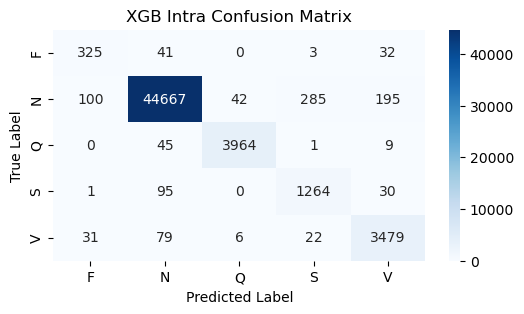

In [31]:
# generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
classes = le.classes_ # ['F', 'N', 'Q', 'S', 'V']

# plot
plt.figure(figsize=(6, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.title('XGB Intra Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

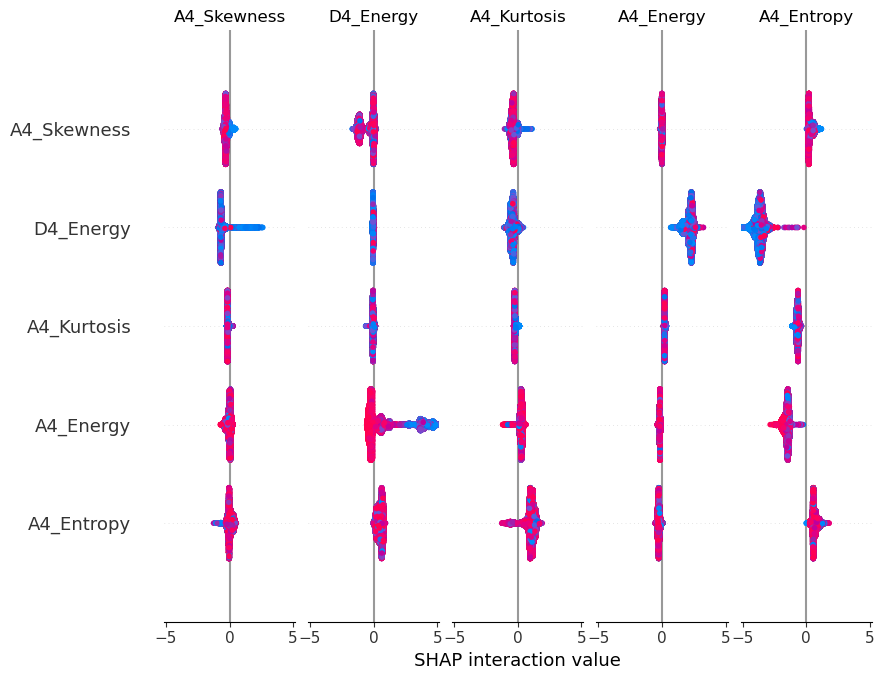

In [32]:
# get the best estimator from GridSearchCV
best_pipeline = grid_xgb.best_estimator_

# extract the actual XGBoost model from the 'model' step of that pipeline
best_model = best_pipeline.named_steps['model']

# pass the actual XGBoost model to TreeExplainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# plot
with warnings.catch_warnings():
    # This specifically targets the NumPy RNG warning inside SHAP
    warnings.filterwarnings("ignore", message=".*NumPy global RNG.*")
    shap.summary_plot(shap_values, X_test)

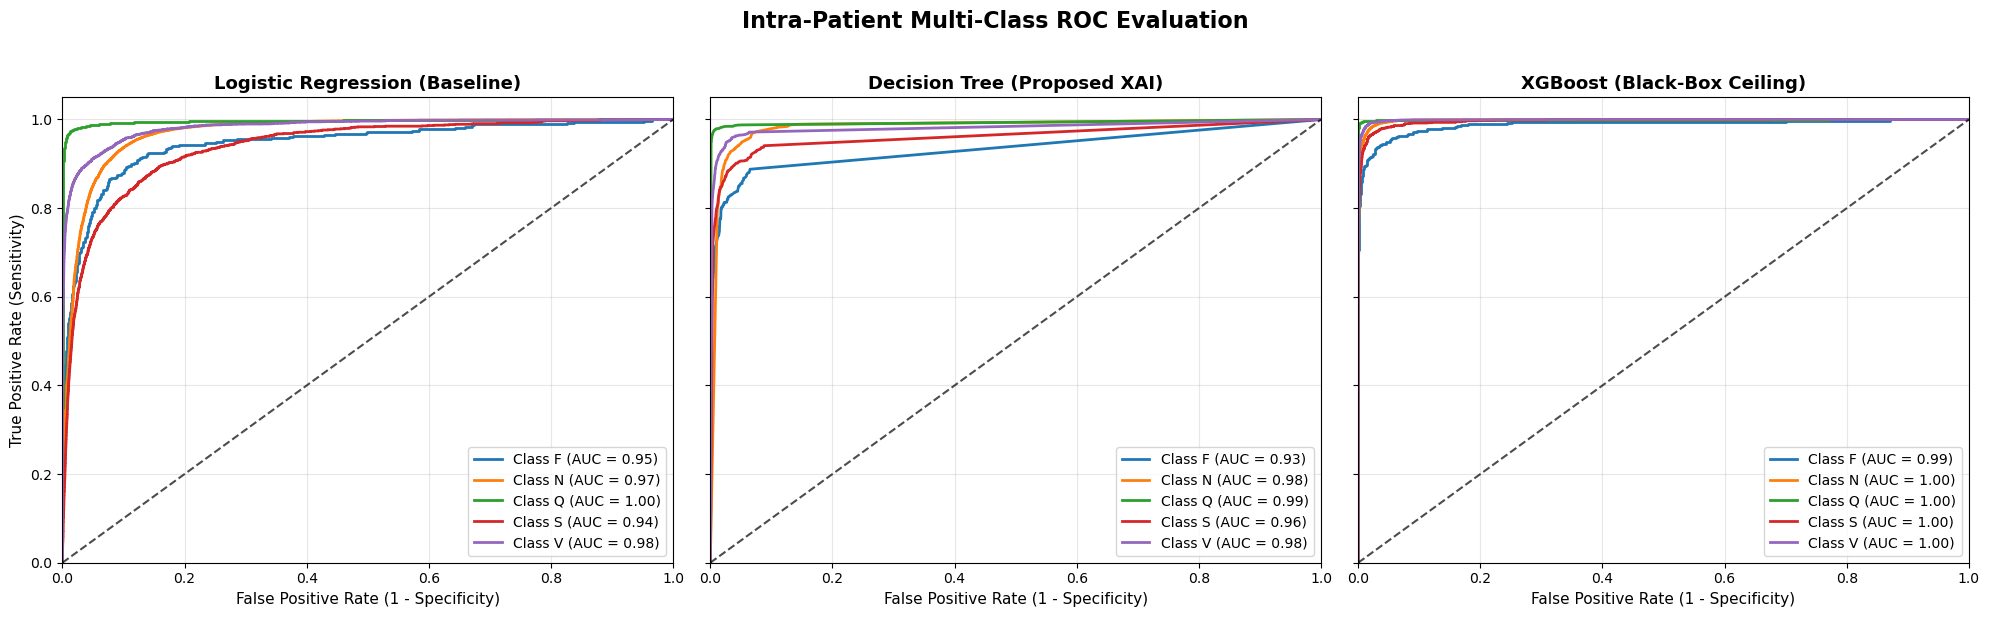

In [33]:
# binarize the true labels across your 5 target classes
# ensuring alphabetical order to match Scikit-Learn's default internal tracking
classes = ['F', 'N', 'Q', 'S', 'V']
y_test_binarized = label_binarize(y_test, classes=classes)
n_classes = len(classes)

# extract predicted probabilities from your three optimized pipelines
# XGBoost uses its own internal LabelEncoder, so we must map its outputs back to our global class order
xgb_internal_order = list(le.classes_)  # Internal order of your LabelEncoder
xgb_order_mapping = [xgb_internal_order.index(c) for c in classes]

y_score_lr = grid_lr.predict_proba(X_test)
y_score_dt = grid_dt.predict_proba(X_test)
y_score_xgb_raw = grid_xgb.predict_proba(X_test)
y_score_xgb = y_score_xgb_raw[:, xgb_order_mapping]  # Re-align to ['F', 'N', 'Q', 'S', 'V']

# setup the 1x3 visualization grid
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
models_metadata = [
    ('Logistic Regression (Baseline)', y_score_lr, axes[0]),
    ('Decision Tree (Proposed XAI)', y_score_dt, axes[1]),
    ('XGBoost (Black-Box Ceiling)', y_score_xgb, axes[2])
]

# iteratively calculate and plot ROC curves per model
for model_name, y_score, ax in models_metadata:
    # Compute ROC curve and ROC area for each individual class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
        # Plot class line
        ax.plot(
            fpr[i], tpr[i], 
            label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})',
            linewidth=2
        )
    
    # plot reference line for a completely random classifier
    ax.plot([0, 1], [0, 1], color='black', linestyle='--', alpha=0.7)
    
    # Visual hygiene adjustments
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
    if ax == axes[0]:
        ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
    ax.set_title(f'{model_name}', fontsize=13, fontweight='bold')
    ax.legend(loc="lower right", fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Intra-Patient Multi-Class ROC Evaluation', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Result And Analysis Of The Intra-Patient Split
| Class /Beat       | Performance Metric  | XGB (intra) | DT (intra) | LR (intra) |
| :---------------- | :------------------ | :---------: | :--------: | :--------: |
| **GLOBAL SCORES** | **Accuracy**        |     0.98    |    0.92    |    0.75    |
|                   | **Weighted Avg F1** |     0.98    |    0.93    |    0.81    |
|                   | **Macro Avg F1**    |     0.91    |    0.74    |    0.57    |
| **CLASS F**       | Precision           |     0.71    |    0.21    |    0.03    |
| *(Fusion)*        | Recall              |     0.81    |    0.81    |    0.53    |
|                   | **F1-Score**        |   **0.76**  |  **0.34**  |  **0.06**  |
| **CLASS N**       | Precision           |     0.99    |    0.99    |    0.98    |
| *(Normal)*        | Recall              |     0.99    |    0.92    |    0.73    |
|                   | **F1-Score**        |   **0.99**  |  **0.96**  |  **0.84**  |
| **CLASS Q**       | Precision           |     0.99    |    0.92    |    0.89    |
| *(Unknown)*       | Recall              |     0.99    |    0.98    |    0.91    |
|                   | **F1-Score**        |   **0.99**  |  **0.95**  |  **0.90**  |
| **CLASS S**       | Precision           |     0.80    |    0.46    |    0.23    |
| *(S-Ventricular)* | Recall              |     0.91    |    0.87    |    0.74    |
|                   | **F1-Score**        |   **0.85**  |  **0.60**  |  **0.36**  |
| **CLASS V**       | Precision           |     0.93    |    0.79    |    0.57    |
| *(Ventricular)*   | Recall              |     0.96    |    0.93    |    0.87    |
|                   | **F1-Score**        |   **0.95**  |  **0.85**  |  **0.69**  |





The DT model achieved macro-F1 score of 74%, a significant improvement from 57% from the LR model. This improvement is characteristic of the intra-patient setting, where patient-specific patterns may be shared between the training and testing sets. Precision for Normal(N) beat was however 99% while recall was 92%. A substantial performace gain from the LR model whose recall for N was 73%.

Similar improvements can be observed with other minority beats like V, S, F, and Q highlighting significant performance gains over the LR model with mininal trade-off in explainabilty.  

Analysis of the confusion matrix showed the gains were due to improved recall values from N beats. In the LR model, linear decision boundaries are not sufficient in characterising some N samples, which lead to many of them being misclassified as S, F, V and Q. Providing more context to the data, the DT model was able to capture more patient-specific relationship between the features and the classes through hierarchical splits. Consequently, the precision and recall for minority classes such as V, S, and Q improved significantly.

In addition the DT made it easy to see the reason why the model classified a beat as N or V. From printed tree, the professional can see the rules guiding each decision by the model. For example, if Pre_RR <= -0.068, RR_Ratio <= -0.413, D3_Energy <= -0.578, the beat was most likely an V. With the same sequence, a beat could likely also be classified F if Pre_RR <  -0.578. This immediately gives an insight on what the leading feature is for each class of beats and which is most discriminative feature among the classes providing interpretable decision thresholds that may correspond to physiological patterns unlike what is obtainable with the LR model.

On the other hand, the XGB provides an even better f1_score of 91%  compared to the decision tree. Precision metrics for the minority classes were also significantly improved, especially for F, S and V classes. F particularly recorded the highest precision gain to 71% from DT's 21% and LR's 9%, because DT and LR models frequently misclassified more N as F, as observed in the confusion matrix. But this is also a very large model in comparative terms, with an ensemble of 200 estimators of depth 10 each. However, the decision process is less interpretable compared to DT due to the ensemble structure. SHAP analysis successfully identified the global top feature drivers in such ensembles, but the magnitude or how they inform the model decision was still largely not as transparent. 

Overall, these results highlight a trade-off between interpretability and predictive performance. The DT model offers a balance between accuracy and explainability, making it suitable for resource-constrained or clinically interpretable settings, whereas XGBoost provides superior performance but with reduced transparency. This trade-off should be considered carefully when selecting models for deployment in real-world ECG monitoring systems

### Inter-Patient Mode:

In [34]:
# this gets the labels from the column 'Label'
def get_record_priority_label(group):
    # order by rarity: F and S are usually rarest in MIT-BIH
    priority = ['F', 'S', 'Q', 'V', 'N'] 
    for label in priority:
        if label in group.values:
            return label
    return 'N'

# create a mapping: Record_ID -> Priority_Label
record_labels = df_cleaned.groupby('Record_ID')['Label'].apply(get_record_priority_label)

# convert to a dataFrame for splitting
stratify_df = pd.DataFrame({
    'Record_ID': record_labels.index,
    'Stratify_Key': record_labels.values
})

In [35]:
# stratified split by Record_IDs
train_ids, test_ids = train_test_split(
    stratify_df['Record_ID'], 
    test_size=0.50, 
    random_state=42, 
    stratify=stratify_df['Stratify_Key'] 
)

# create the actual training and testing DataFrames
df_train = df_cleaned[df_cleaned['Record_ID'].isin(train_ids)].copy()
df_test = df_cleaned[df_cleaned['Record_ID'].isin(test_ids)].copy()

print(f"Records for Training: {len(train_ids)}")
print(f"Records for Testing:  {len(test_ids)}")
print(f"---")
print(f"Total Beats in Train: {len(df_train)}")
print(f"Total Beats in Test:  {len(df_test)}")

Records for Training: 24
Records for Testing:  24
---
Total Beats in Train: 54341
Total Beats in Test:  55091


In [36]:
# Convert lists to sets for math operations
train_set = set(train_ids)
test_set = set(test_ids)

# Check for overlap
overlap = train_set.intersection(test_set)

print(f"Number of overlapping IDs: {len(overlap)}")

if len(overlap) == 0:
    print("SUCCESS: No patient leakage. The training and testing sets are completely independent.")
else:
    print(f"WARNING: Found leakage! Overlapping IDs: {overlap}")

print(f"Training Patient IDs: {sorted(list(train_set))}")
print(f"Testing Patient IDs:  {sorted(list(test_set))}")

Number of overlapping IDs: 0
SUCCESS: No patient leakage. The training and testing sets are completely independent.
Training Patient IDs: [100, 101, 102, 103, 105, 107, 108, 109, 111, 113, 116, 119, 121, 124, 201, 205, 212, 215, 221, 222, 223, 228, 232, 233]
Testing Patient IDs:  [104, 106, 112, 114, 115, 117, 118, 122, 123, 200, 202, 203, 207, 208, 209, 210, 213, 214, 217, 219, 220, 230, 231, 234]


In [37]:
print("\nTrain Label Distribution:")
print(df_train['AAMI_Label'].value_counts())

print("\nTest Label Distribution:")
print(df_test['AAMI_Label'].value_counts())


Train Label Distribution:
AAMI_Label
N    44982
Q     4167
V     3256
S     1888
F       48
Name: count, dtype: int64

Test Label Distribution:
AAMI_Label
N    45596
V     3979
Q     3871
S      891
F      754
Name: count, dtype: int64


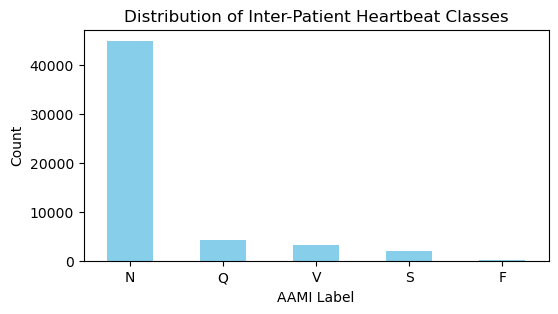

In [38]:
# This one-liner will create the bar chart
df_train['AAMI_Label'].value_counts().plot(kind='bar', figsize=(6, 3), color='skyblue')

plt.title('Distribution of Inter-Patient Heartbeat Classes')
plt.xlabel('AAMI Label')
plt.ylabel('Count')
plt.xticks(rotation=0) # Keeps the letters N, S, V, etc. upright
plt.show()

In [39]:
# List of your feature columns
feature_cols = df_cleaned.drop(columns=['Label', 'Record_ID','AAMI_Label']).columns.tolist()


# Prepare Training Data
X_train = df_train[feature_cols]
y_train = df_train['AAMI_Label']

# Prepare Testing Data
X_test = df_test[feature_cols]
y_test = df_test['AAMI_Label']


### Inter-Patient: Logistic Regression Training And Classification

In [40]:
# standardized pipeline
pipeline_lr = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('under', RandomUnderSampler(random_state=42)),
    ('over', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=2000, solver='lbfgs'))
])

# parameter grid
param_grid_lr = {
    # Test uniform target sizes for the majority class
    'under__sampling_strategy': [{'N': 10000}, {'N': 15000}, {'N': 20000}, {'N': 25000}, {'N': 30000}],
    'over__sampling_strategy': ['auto'], # SMOTE brings others up to match 'N'
    
    # Model tuning
    'over__k_neighbors': [3, 5],
    'model__C': [0.1, 1.0, 10.0]
}
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

grid_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid_lr,
    scoring='f1_macro',  # f_1 metric
    cv=sgkf,  
    n_jobs=-1,
    verbose=1
)
# extract group IDs (Make sure this matches your training dataframe name)
groups_train = df_train['Record_ID']

# fit the search
print("Tuning both sampling size and model parameters...")
grid_lr.fit(X_train, y_train, groups=groups_train)

# print the best parameters and scores
print(f"Best Target Size & Params: {grid_lr.best_params_}")
print(f"Best CV Score: {grid_lr.best_score_:.4f}")

Tuning both sampling size and model parameters...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Target Size & Params: {'model__C': 0.1, 'over__k_neighbors': 5, 'over__sampling_strategy': 'auto', 'under__sampling_strategy': {'N': 20000}}
Best CV Score: 0.3022


In [41]:
# Results
best_index = grid_lr.best_index_
mean_cv_score = grid_lr.cv_results_['mean_test_score'][best_index]
std_cv_score = grid_lr.cv_results_['std_test_score'][best_index]
print(f"CV Standard Deviation: {std_cv_score}")
print(f"CV Mean F1-Score: {mean_cv_score}")

CV Standard Deviation: 0.07431308658783552
CV Mean F1-Score: 0.3021758060502767


In [42]:
print("LR Inter Classification Report")
y_pred_lr = grid_lr.predict(X_test)
print(classification_report(y_test, y_pred_lr))

LR Inter Classification Report
              precision    recall  f1-score   support

           F       0.05      0.54      0.08       754
           N       0.97      0.67      0.80     45596
           Q       0.84      0.81      0.83      3871
           S       0.10      0.46      0.17       891
           V       0.52      0.87      0.65      3979

    accuracy                           0.69     55091
   macro avg       0.50      0.67      0.50     55091
weighted avg       0.90      0.69      0.77     55091



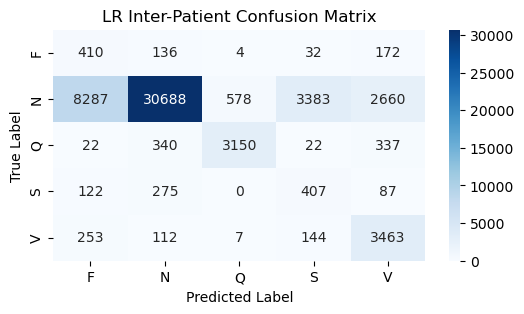

In [43]:
# generate confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
labels = sorted(y_test.unique())

# plot
plt.figure(figsize=(6, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('LR Inter-Patient Confusion Matrix')
plt.show()

### Inter-Patient: Decision Tree Training And Classification

In [44]:
# define the Pipeline
pipeline_dt = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('under', RandomUnderSampler(random_state=42)),
    ('over', SMOTE(random_state=42)),
    ('model', DecisionTreeClassifier(random_state=42))
])

# define the Grid
param_grid_dt = {
    # Identical sampling strategy
    'under__sampling_strategy': [{'N': 10000}, {'N': 15000}, {'N': 20000}, {'N': 25000}, {'N': 30000}],
    'over__sampling_strategy': ['auto'],
    
    # Tamed hyperparameters to prevent severe overfitting
    'model__max_depth': [4, 6, 8, 10, 12, 14],         
    'model__min_samples_leaf': [30, 50, 100],  # Increased to force generalization
    'model__criterion': ['gini', 'entropy'],
    'model__class_weight': [None]            
}

# setup grid search
skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

grid_dt = GridSearchCV(
    estimator=pipeline_dt,
    param_grid=param_grid_dt,
    cv=skf,
    scoring='f1_macro',  # f_1 metric
    n_jobs=-1,              
    verbose=1
)
# extract group IDs (Make sure this matches your training dataframe name)
groups_train = df_train['Record_ID']

# fit
grid_dt.fit(X_train, y_train, groups=groups_train)

print(f"Best Parameters: {grid_dt.best_params_}")
print(f"Best CV Score: {grid_dt.best_score_:.4f}")# define the Pipeline

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best Parameters: {'model__class_weight': None, 'model__criterion': 'entropy', 'model__max_depth': 6, 'model__min_samples_leaf': 30, 'over__sampling_strategy': 'auto', 'under__sampling_strategy': {'N': 25000}}
Best CV Score: 0.3320


In [26]:
# Results
best_index = grid_dt.best_index_
mean_cv_score = grid_dt.cv_results_['mean_test_score'][best_index]
std_cv_score = grid_dt.cv_results_['std_test_score'][best_index]
print(f"CV Standard Deviation: {std_cv_score}")
print(f"CV Mean F1-Score: {mean_cv_score}")

CV Standard Deviation: 0.07981239924525127
CV Mean F1-Score: 0.3319888360914174


In [45]:
# classification report
print("DT Inter Classification Report")
y_pred_dt = grid_dt.predict(X_test)
print(classification_report(y_test, y_pred_dt))

DT Inter Classification Report
              precision    recall  f1-score   support

           F       0.02      0.54      0.04       754
           N       0.95      0.56      0.71     45596
           Q       0.80      0.79      0.79      3871
           S       0.11      0.24      0.15       891
           V       0.68      0.79      0.73      3979

    accuracy                           0.59     55091
   macro avg       0.51      0.59      0.49     55091
weighted avg       0.89      0.59      0.70     55091



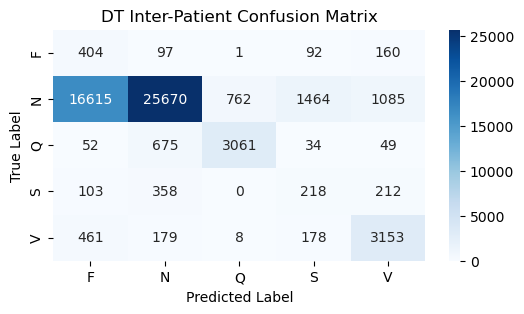

In [46]:
# generate confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)
labels = sorted(y_test.unique())

# plot
plt.figure(figsize=(6, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('DT Inter-Patient Confusion Matrix')
plt.show()

In [57]:
# Extract the actual tree from the 'model' step of the pipeline
feature_names = X_test.columns.tolist()
best_pipeline = grid_dt.best_estimator_
tree_model = best_pipeline.named_steps['model']

# Now export the logic using the extracted tree
tree_rules = export_text(tree_model, feature_names=feature_names)
print(tree_rules)

|--- D1_Entropy <= -0.54
|   |--- A4_Kurtosis <= -0.15
|   |   |--- D3_Energy <= 0.02
|   |   |   |--- Pre_RR <= -0.41
|   |   |   |   |--- D2_Skewness <= 0.44
|   |   |   |   |   |--- D2_Skewness <= -1.31
|   |   |   |   |   |   |--- class: Q
|   |   |   |   |   |--- D2_Skewness >  -1.31
|   |   |   |   |   |   |--- class: S
|   |   |   |   |--- D2_Skewness >  0.44
|   |   |   |   |   |--- D2_Entropy <= -0.79
|   |   |   |   |   |   |--- class: V
|   |   |   |   |   |--- D2_Entropy >  -0.79
|   |   |   |   |   |   |--- class: V
|   |   |   |--- Pre_RR >  -0.41
|   |   |   |   |--- Post_RR <= -0.03
|   |   |   |   |   |--- Pre_RR <= -0.08
|   |   |   |   |   |   |--- class: N
|   |   |   |   |   |--- Pre_RR >  -0.08
|   |   |   |   |   |   |--- class: Q
|   |   |   |   |--- Post_RR >  -0.03
|   |   |   |   |   |--- Pre_RR <= 0.53
|   |   |   |   |   |   |--- class: Q
|   |   |   |   |   |--- Pre_RR >  0.53
|   |   |   |   |   |   |--- class: Q
|   |   |--- D3_Energy >  0.02
|   |   |  

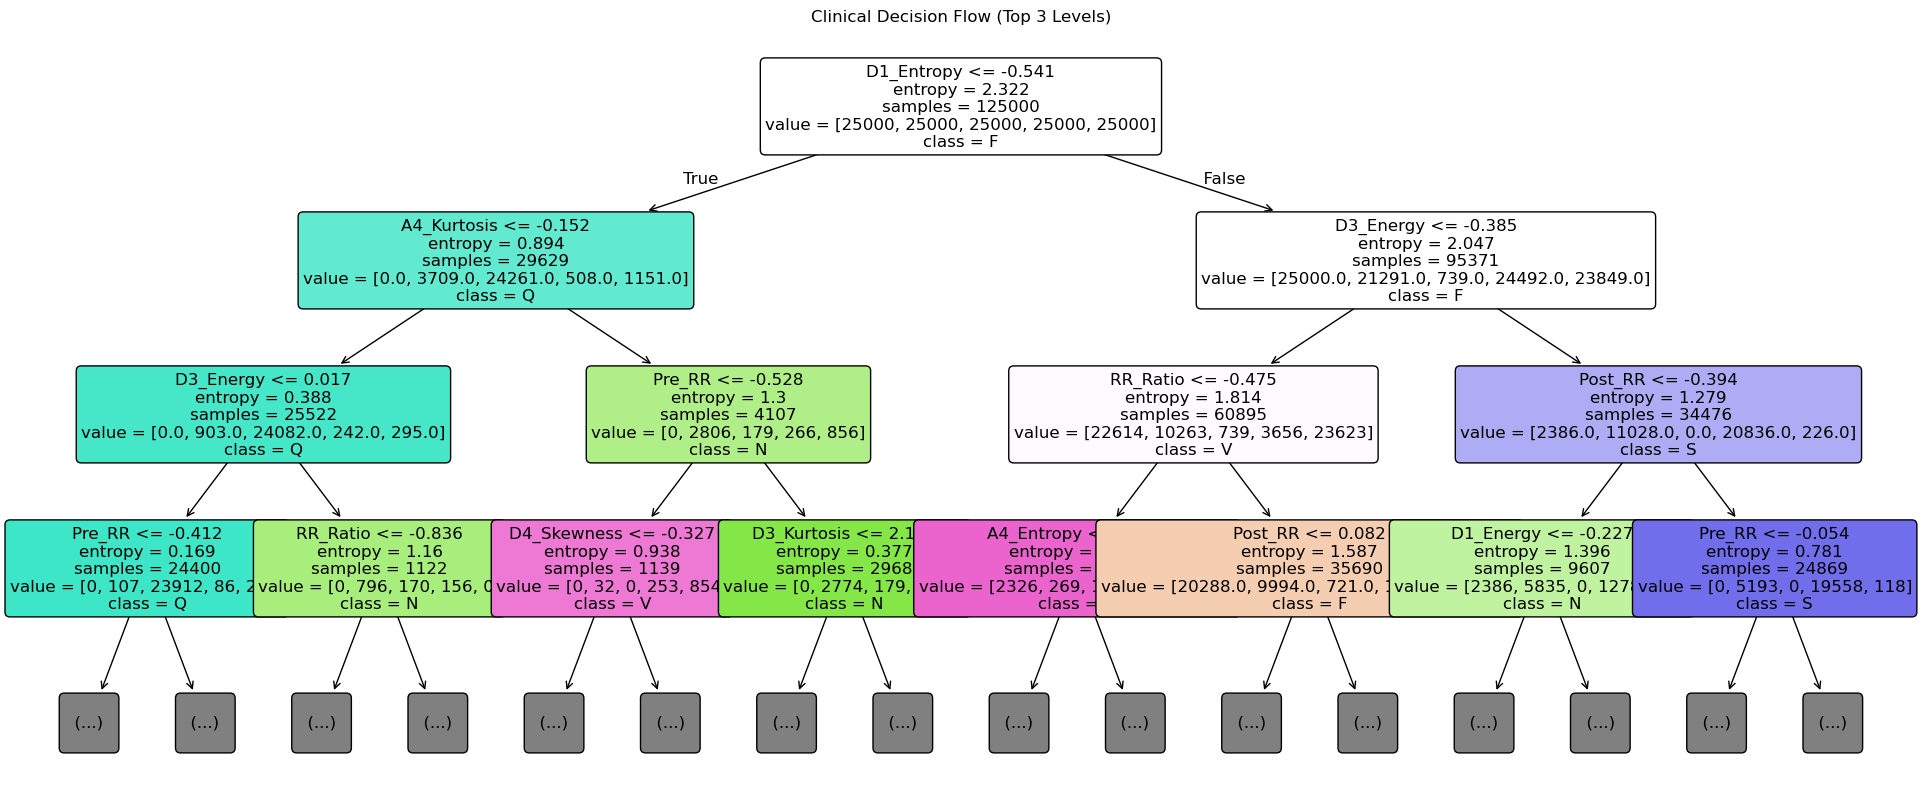

In [48]:
# extract the trained tree from the 'model' step
tree_to_plot = best_pipeline.named_steps['model']

# pass the extracted tree (not the pipeline) to plot_tree
plt.figure(figsize=(24, 10))
plot_tree(
    tree_to_plot,                
    max_depth=3,                  
    feature_names=feature_names,   
    class_names=labels,            
    filled=True,                   
    rounded=True,      
    fontsize=12     
)
plt.title("Clinical Decision Flow (Top 3 Levels)")
plt.show()

### Inter-Patient: Training And Classification With XGBOOST

In [49]:
# label encoding
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

# define the Pipeline
xgb_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('under', RandomUnderSampler(random_state=42)),
    ('over', SMOTE(random_state=42)),
    ('model', XGBClassifier(random_state=42))
])

# define the hyperparameter grid
N_encoded = le.transform(['N'])[0]
param_grid_xgb = {
    # Identical sampling strategy using the encoded integer key
    'under__sampling_strategy': [{N_encoded: 10000}, {N_encoded: 15000}, {N_encoded: 20000}, {N_encoded: 25000},{N_encoded: 30000}], 
    'over__sampling_strategy': ['auto'],
    
    # hyperparameters
    'model__n_estimators': [100, 200],
    'model__max_depth': [4, 6, 8, 10],            
    'model__learning_rate': [0.1],
    'model__subsample': [0.8],
    'model__eval_metric': ['mlogloss']
}

# setup grid search
xgbkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

grid_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    cv=xgbkf,
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1
)

groups_train = df_train['Record_ID']

# training
print("Starting Resampled Cross-Validation for XGBoost...")
grid_xgb.fit(X_train, y_train_encoded, groups=groups_train)

print(f"\nBest Parameters: {grid_xgb.best_params_}")
print(f"Best CV Score: {grid_xgb.best_score_:.4f}")

Starting Resampled Cross-Validation for XGBoost...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Parameters: {'model__eval_metric': 'mlogloss', 'model__learning_rate': 0.1, 'model__max_depth': 8, 'model__n_estimators': 200, 'model__subsample': 0.8, 'over__sampling_strategy': 'auto', 'under__sampling_strategy': {np.int64(1): 20000}}
Best CV Score: 0.3836


In [50]:
# Results
best_index = grid_xgb.best_index_
mean_cv_score = grid_xgb.cv_results_['mean_test_score'][best_index]
std_cv_score = grid_xgb.cv_results_['std_test_score'][best_index]
print(f"CV Standard Deviation: {std_cv_score}")
print(f"CV Mean F1-Score: {mean_cv_score}")

CV Standard Deviation: 0.06330125510513018
CV Mean F1-Score: 0.38355199131907325


In [53]:
# confusion matrix
best_pipeline = grid_xgb.best_estimator_
y_pred_encoded = best_pipeline.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_encoded)
print("\n XGBoost Inter Classification Report")
print(classification_report(y_test, y_pred_xgb))


 XGBoost Inter Classification Report
              precision    recall  f1-score   support

           F       0.10      0.09      0.10       754
           N       0.96      0.90      0.93     45596
           Q       0.97      0.84      0.90      3871
           S       0.14      0.27      0.19       891
           V       0.52      0.90      0.66      3979

    accuracy                           0.87     55091
   macro avg       0.54      0.60      0.55     55091
weighted avg       0.91      0.87      0.89     55091



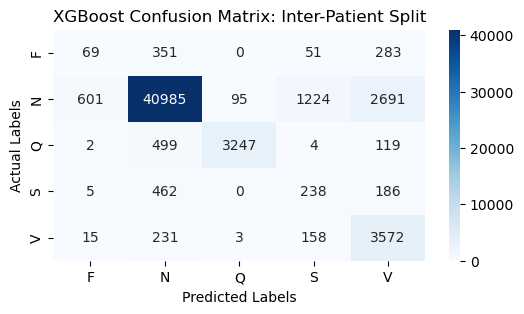

In [54]:
# generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
classes = le.classes_ # ['F', 'N', 'Q', 'S', 'V']

# plot
plt.figure(figsize=(6, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.title('XGBoost Confusion Matrix: Inter-Patient Split')
plt.ylabel('Actual Labels')
plt.xlabel('Predicted Labels')
plt.show()

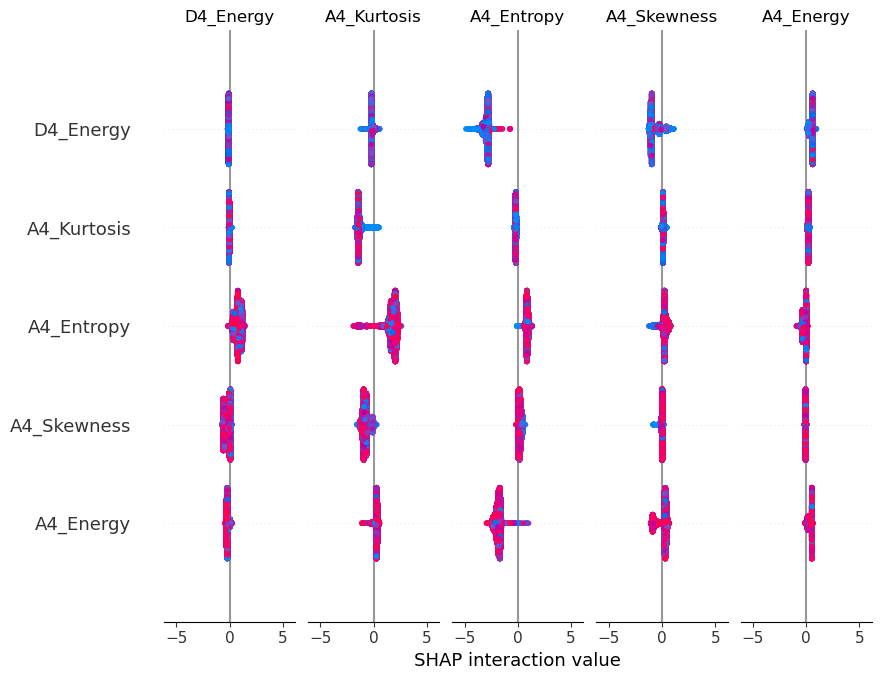

In [55]:
# get the best estimator from GridSearchCV
best_pipeline = grid_xgb.best_estimator_

# extract the actual XGBoost model from the 'model' step of that pipeline
best_model = best_pipeline.named_steps['model']

# pass the actual XGBoost model to TreeExplainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# plot
with warnings.catch_warnings():
    # This specifically targets the NumPy RNG warning inside SHAP
    warnings.filterwarnings("ignore", message=".*NumPy global RNG.*")
    shap.summary_plot(shap_values, X_test)

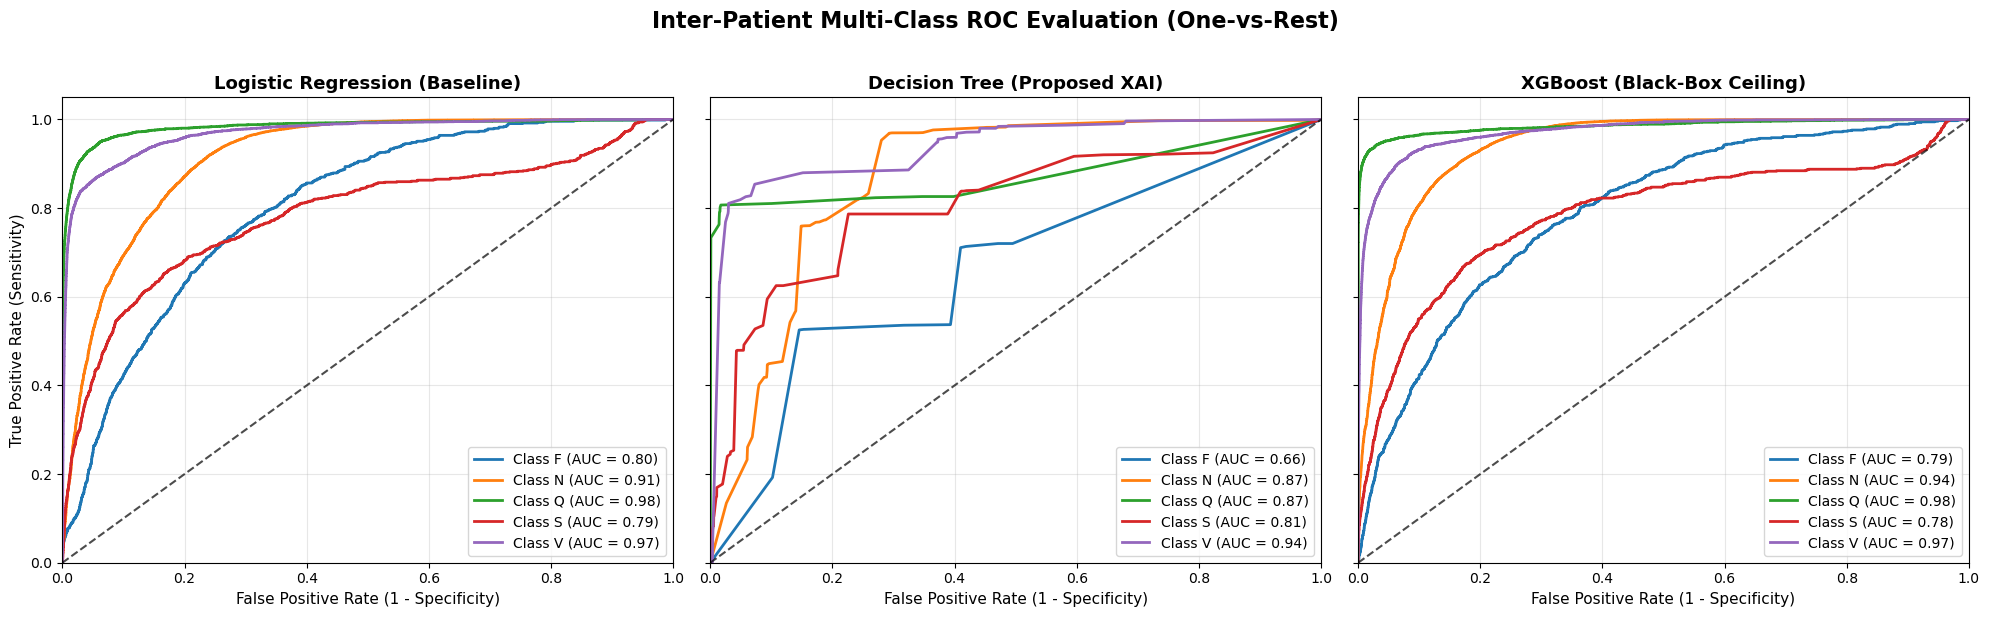

In [56]:
# ensuring alphabetical order to match Scikit-Learn's default internal tracking
classes = ['F', 'N', 'Q', 'S', 'V']
y_test_binarized = label_binarize(y_test, classes=classes)
n_classes = len(classes)

# extract predicted probabilities from your three optimized pipelines
# XGBoost uses its own internal LabelEncoder, so we must map its outputs back to our global class order
xgb_internal_order = list(le.classes_)  # Internal order of your LabelEncoder
xgb_order_mapping = [xgb_internal_order.index(c) for c in classes]

y_score_lr = grid_lr.predict_proba(X_test)
y_score_dt = grid_dt.predict_proba(X_test)
y_score_xgb_raw = grid_xgb.predict_proba(X_test)
y_score_xgb = y_score_xgb_raw[:, xgb_order_mapping]  # Re-align to ['F', 'N', 'Q', 'S', 'V']

# setup the 1x3 visualization grid
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
models_metadata = [
    ('Logistic Regression (Baseline)', y_score_lr, axes[0]),
    ('Decision Tree (Proposed XAI)', y_score_dt, axes[1]),
    ('XGBoost (Black-Box Ceiling)', y_score_xgb, axes[2])
]

# iteratively calculate and plot ROC curves per model
for model_name, y_score, ax in models_metadata:
    # Compute ROC curve and ROC area for each individual class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
        # Plot class line
        ax.plot(
            fpr[i], tpr[i], 
            label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})',
            linewidth=2
        )
    
    # plot reference line for a completely random classifier
    ax.plot([0, 1], [0, 1], color='black', linestyle='--', alpha=0.7)
    
    # Visual hygiene adjustments
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
    if ax == axes[0]:
        ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
    ax.set_title(f'{model_name}', fontsize=13, fontweight='bold')
    ax.legend(loc="lower right", fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Inter-Patient Multi-Class ROC Evaluation (One-vs-Rest)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Result And Analysis Of The Inter-Patient Split
| Class / Metric    | Performance Category | XGB (Inter) | DT (Inter) | LR (Inter) |
| :---------------- | :------------------- | :-----------------: | :-----------: | :-----------------: |
| **GLOBAL SCORES** | **Accuracy**         |       **0.87**      |    **0.59**   |       **0.69**      |
|                   | **Weighted Avg F1**  |       **0.89**      |    **0.70**   |       **0.77**      |
|                   | **Macro Avg F1**     |       **0.55**      |    **0.49**   |       **0.50**      |
| **CLASS V**       | Precision            |         0.52        |      0.68     |         0.52        |
| *(Ventricular)*   | Recall               |         0.90        |      0.79     |         0.87        |
|                   | **F1-Score**         |       **0.66**      |    **0.73**   |       **0.65**      |
| **CLASS S**       | Precision            |         0.14        |      0.11     |         0.10        |
| *(S-Ventricular)* | Recall               |         0.27        |      0.24     |         0.46        |
|                   | **F1-Score**         |       **0.19**      |    **0.15**   |       **0.17**      |
| **CLASS F**       | Precision            |         0.10        |      0.02     |         0.05        |
| *(Fusion)*        | Recall               |         0.09        |      0.54     |         0.54        |
|                   | **F1-Score**         |       **0.10**      |    **0.04**   |       **0.08**      |
| **CLASS Q**       | Precision            |         0.97        |      0.80     |         0.84        |
| *(Unknown)*       | Recall               |         0.84        |      0.79     |         0.81        |
|                   | **F1-Score**         |       **0.90**      |    **0.79**   |       **0.83**      |
| **CLASS N**       | Precision            |         0.96        |      0.95     |         0.97        |
| *(Normal)*        | Recall               |         0.90        |      0.56     |         0.67        |
|                   | **F1-Score**         |       **0.93**      |    **0.71**   |       **0.80**      |


For the inter-patient classification task, the DT model achieved an overall accuracy of 59%, degrading significantly from the 69% obtained with the LR model. Also the macro-F1 score of the DT model (0.49) was slightly lower than that of LR (0.50). 

In both models, these results highlight the increased difficulty of the inter-patient setting, where models must generalize across unseen patient morphologies rather than relying on patient-specific patterns. While the DT model improved precision for the V class (0.68 vs 0.52 in LR), its performance on other minority classes such as S and F remained limited.

In particular, all three models struggled significantly with minority beat classes, especially F and S, where both precision and F1-scores remained low. Although LR achieved relatively high recall for the F class (0.54), this came at the cost of extremely low precision (0.05), indicating a large number of false positives. This suggests that the models were unable to reliably distinguish minority beat morphologies across unseen patients.

The XGB model achieved the strongest overall performance, with improvements across accuracy, weighted-F1, and macro-F1 metrics. Performance gains were especially evident in the N and Q classes, where both recall and F1-score improved compared to DT and LR. However, despite these improvements, performance on minority classes remained poor overall, particularly for the F and S classes.

These results demonstrate the difficulty of inter-patient ECG classification, where variability in patient-specific morphology significantly reduces model generalization. Although XGBoost provides the best overall performance, the persistently low minority-class performance across all models suggests that additional strategies, such as improved feature engineering, data balancing, or patient-invariant representations, may be required for reliable deployment in clinical settings.

### Conclusion:
The results demonstrate the trade-offs between predictive performance, interpretability, and model complexity in ECG beat classification. While the decision tree (DT) model provides improved interpretability and portability compared to the black-box XGBoost (XGB) model, this comes at the cost of reduced predictive performance, particularly in the intra-patient setting where XGB achieved substantially higher scores across most metrics.

In the inter-patient setting, however, the performance gap between DT and XGB becomes smaller, as both models experience significant degradation in their ability to generalize to unseen patient data. This highlights the difficulty of inter-patient ECG classification, where variations in patient-specific morphology reduce model robustness across different subjects.

Although hybrid resampling strategies were applied to reduce class imbalance, all models continued to struggle with minority classes, particularly S and F beats. This suggests that the generated synthetic samples may not have introduced sufficient diversity to adequately represent unseen minority-class feature distributions.

Future work should therefore explore more advanced generative augmentation techniques capable of producing more diverse and representative minority-class samples. In particular, deep generative models may help improve generalization by expanding the variability of minority-class feature spaces across unseen patients.